In [490]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

In [491]:
def get_revisions(page_title, talk=False):
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    endpoint = "https://en.wikipedia.org/w/api.php"
    headers = {
        "User-Agent": "WikiResearchBot/0.1 (t.j.wies@gmail.com)"
    }

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(endpoint, params=params, headers=headers, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return all_revisions

def format_revisions(revisions):
    df = pd.DataFrame(revisions)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")

    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    features = pd.concat([edits, unique_editors, new_editors], axis=1).fillna(0)

    return features.sort_values("timestamp")

In [492]:
revisions = get_revisions("Talk:2026_Iran_war", talk=True)
print(len(revisions))
features = format_revisions(revisions)
features.head()

3817


,edits,unique_editors,new_editors
timestamp,,,
2026-02-28 06:00:00+00:00,5,5,5
2026-02-28 07:00:00+00:00,24,12,12
2026-02-28 08:00:00+00:00,9,8,5
2026-02-28 09:00:00+00:00,21,9,6
2026-02-28 10:00:00+00:00,8,5,4


In [493]:
import json
from datetime import datetime, timedelta, timezone

import pandas as pd
import requests


GAMMA = "https://gamma-api.polymarket.com"
CLOB = "https://clob.polymarket.com"

HEADERS = {
    "User-Agent": "research-script/0.1 (you@example.com)"
}


def _maybe_json_load(value):
    if isinstance(value, str):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            return value
    return value


def fetch_event_by_slug(slug: str, headers: dict | None = None) -> dict:
    headers = headers or HEADERS

    resp = requests.get(
        f"{GAMMA}/events",
        params={"slug": slug},
        headers=headers,
        timeout=20,
    )
    resp.raise_for_status()
    data = resp.json()

    if isinstance(data, list):
        if not data:
            raise ValueError(f"No event found for slug '{slug}'")
        return data[0]

    if not data:
        raise ValueError(f"No event found for slug '{slug}'")

    return data


def extract_market_tokens(event: dict) -> list[dict]:
    rows = []

    for market in event.get("markets", []):
        outcomes = _maybe_json_load(market.get("outcomes"))
        clob_ids = _maybe_json_load(market.get("clobTokenIds"))

        if not outcomes or not clob_ids:
            continue

        if len(outcomes) != len(clob_ids):
            continue

        token_map = dict(zip(outcomes, clob_ids))

        rows.append(
            {
                "market_question": market.get("question"),
                "market_slug": market.get("slug"),
                "token_map": token_map,
            }
        )

    if not rows:
        raise ValueError("No markets with token IDs found in event.")

    return rows


def get_yes_token_from_event(event: dict, market_question_contains: str | None = None) -> tuple[str, str]:
    markets = extract_market_tokens(event)

    if market_question_contains:
        needle = market_question_contains.lower()
        markets = [
            m for m in markets
            if needle in (m["market_question"] or "").lower()
        ]
        if not markets:
            raise ValueError(
                f"No market question matched substring: {market_question_contains!r}"
            )

    for m in markets:
        token_map = m["token_map"]
        if "Yes" in token_map:
            return token_map["Yes"], m["market_question"]

    raise ValueError("No 'Yes' token found in selected markets.")


def fetch_price_history(
    token_id: str,
    days: int = 7,
    interval: str = "1h",
    fidelity: int = 60,
    headers: dict | None = None,
) -> pd.DataFrame:
    headers = headers or HEADERS

    end_ts = int(datetime.now(timezone.utc).timestamp())
    start_ts = int((datetime.now(timezone.utc) - timedelta(days=days)).timestamp())

    resp = requests.get(
        f"{CLOB}/prices-history",
        params={
            "market": token_id,
            "startTs": start_ts,
            "endTs": end_ts,
            "interval": interval,
            "fidelity": fidelity,
        },
        headers=headers,
        timeout=20,
    )
    resp.raise_for_status()
    data = resp.json()

    history = data.get("history", [])
    df = pd.DataFrame(history)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["t"], unit="s", utc=True)
    df = df.rename(columns={"p": "price"}).sort_values("timestamp")
    return df[["timestamp", "price"]]


def get_price_series_from_slug(
    slug: str,
    days: int = 7,
    interval: str = "1h",
    fidelity: int = 60,
    market_question_contains: str | None = None,
    headers: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    headers = headers or HEADERS

    event = fetch_event_by_slug(slug, headers=headers)
    token_id, market_question = get_yes_token_from_event(
        event,
        market_question_contains=market_question_contains,
    )
    df = fetch_price_history(
        token_id,
        days=days,
        interval=interval,
        fidelity=fidelity,
        headers=headers,
    )

    meta = {
        "event_title": event.get("title"),
        "event_slug": event.get("slug"),
        "market_question": market_question,
        "yes_token_id": token_id,
    }

    return df, meta


# Example usage:
slug = "will-the-us-invade-iran-before-2027"

prices, meta = get_price_series_from_slug(
    slug=slug,
    days=7,
    interval="1h",
    fidelity=60,
)

prices.sort_values("timestamp")
print(meta)
print(prices.head())
print(f"Rows returned: {len(prices)}")

{'event_title': 'Will the U.S. invade Iran before 2027?', 'event_slug': 'will-the-us-invade-iran-before-2027', 'market_question': 'Will the U.S. invade Iran before 2027?', 'yes_token_id': '55115078421062885512539156303747803058407616201213034911037320915726138659123'}
                  timestamp  price
0 2026-03-26 17:00:24+00:00  0.645
1 2026-03-26 18:00:21+00:00  0.645
2 2026-03-26 19:00:21+00:00  0.650
3 2026-03-26 20:00:25+00:00  0.650
4 2026-03-26 21:00:23+00:00  0.615
Rows returned: 165


In [494]:
df = pd.merge_asof(prices, features, on="timestamp", direction="backward")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")
windows = ["30min", "1h", "3h", "6h", "12h", "24h"]

for w in windows:
    df[f"edits_{w}"] = df["edits"].rolling(w).sum()
    df[f"edits_{w}_diff"] = df[f"edits_{w}"].diff()
    df[f"delta_price_{w}"] = df["price"].shift(-int(w[0])) - df["price"]
    df[f"abs_delta_price_move_{w}"] = df[f"delta_price_{w}"].abs()
    df[f"unique_editors_{w}"] = df["unique_editors"].rolling(w).sum().diff()
    df[f"new_editors_{w}"] = df["new_editors"].rolling(w).sum().diff()
# edits at time t predicting future
for i in range(1, 20):
    df[f"edits_lag_{i}"] = df[f"edits_30min_diff"].shift(i)
    df[f"new_editors_lag_{i}"] = df[f"new_editors_30min"].shift(i)
    df[f"unique_editors_lag_{i}"] = df["unique_editors_30min"].shift(i)

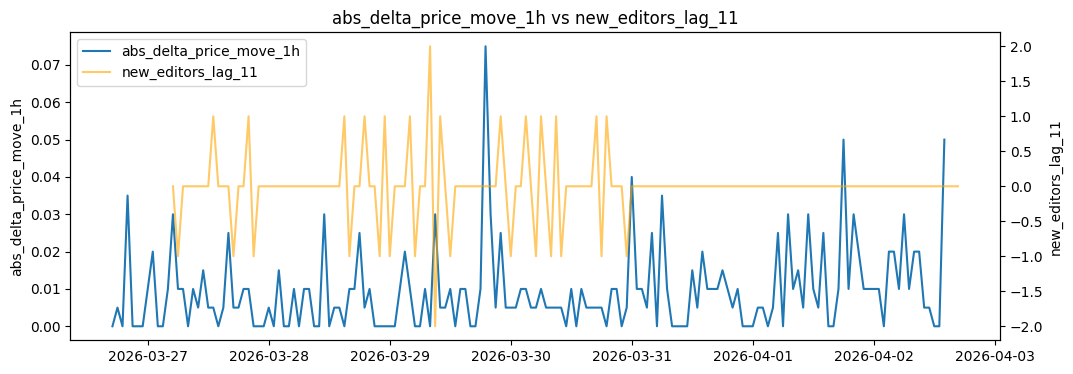

In [495]:
import matplotlib.pyplot as plt

def plot_rolling_delta(col1: str, col2: str):
    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(df.index, df[col1], label=col1)
    ax1.set_ylabel(col1)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df[col2], color="orange", alpha=0.6, label=col2)
    ax2.set_ylabel(col2)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f"{col1} vs {col2}")
    plt.show()


plot_rolling_delta("abs_delta_price_move_1h", "new_editors_lag_11")

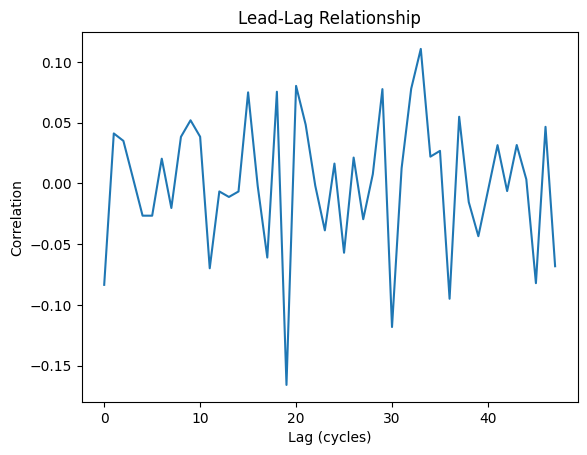

In [496]:
corrs = []

for lag in range(0, 48):
    shifted = df["new_editors_30min"].shift(lag)
    corr = shifted.corr(df["abs_delta_price_move_30min"])
    corrs.append(corr)

import matplotlib.pyplot as plt

plt.plot(range(48), corrs)
plt.xlabel("Lag (cycles)")
plt.ylabel("Correlation")
plt.title("Lead-Lag Relationship")
plt.show()

In [522]:
y = df["abs_delta_price_move_1h"]
X = df[[
    "new_editors_1h",
    "edits_1h_diff",
]
+ [f"new_editors_lag_{i}" for i in range(1,20)]
+ [f"edits_lag_{i}" for i in range(1,20)]
+ [f"unique_editors_lag_{i}" for i in range(1,20)]
]

In [524]:
top10 = (
    X.apply(lambda col: col.corr(y))
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(10)
)

selected_features = []
for name, corr in top10.items():
    print(f"{name}: {corr:.4f}")
    selected_features.append(name)

print(selected_features)

edits_lag_11: -0.1296
edits_lag_13: 0.1217
unique_editors_lag_3: 0.1166
new_editors_lag_3: 0.1155
new_editors_lag_6: -0.1128
unique_editors_lag_15: -0.1049
unique_editors_lag_7: 0.1007
edits_lag_12: 0.0992
unique_editors_lag_16: 0.0990
unique_editors_lag_18: -0.0900
['edits_lag_11', 'edits_lag_13', 'unique_editors_lag_3', 'new_editors_lag_3', 'new_editors_lag_6', 'unique_editors_lag_15', 'unique_editors_lag_7', 'edits_lag_12', 'unique_editors_lag_16', 'unique_editors_lag_18']


In [525]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# target
df["target"] = (df["price"].shift(-3) - df["price"]).abs()

# build clean modeling frame
model_df = pd.concat([df[selected_features], df["target"]], axis=1).dropna()

X_clean = model_df[selected_features]
y_clean = model_df["target"]

# split AFTER dropna
split = int(len(model_df) * 0.7)

X_train = X_clean.iloc[:split]
X_test  = X_clean.iloc[split:]
y_train = y_clean.iloc[:split]
y_test  = y_clean.iloc[split:]

# scale using train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# fit
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# predict
y_pred = model.predict(X_test_scaled)

print("train len:", len(X_train), "test len:", len(X_test))
print("R²:", r2_score(y_test, y_pred))
print("Corr:", np.corrcoef(y_test, y_pred)[0,1])

train len: 100 test len: 43
R²: -0.01110886733148142
Corr: 0.11535489673011377
